#Task One

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report

In [3]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")


In [4]:
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")

print("\n" + "=" * 50)
print("COLUMN NAMES & DATA TYPES")
print("=" * 50)
print(df.dtypes.to_string())

print("\n" + "=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
df.head()

DATASET SHAPE
Rows: 1200  |  Columns: 14

COLUMN NAMES & DATA TYPES
OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64

FIRST 5 ROWS


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
print("=" * 50)
print("BASIC STATISTICS (Numeric Columns)")
print("=" * 50)
df.describe().round(2)

BASIC STATISTICS (Numeric Columns)


,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.00,1200.00,1200.00,1200.00
mean,2024-03-22 16:58:48,2.95,356.41,5.48,1053.97
min,2023-01-01 00:00:00,1.00,11.39,1.00,11.39
25%,2023-08-03 18:00:00,2.00,186.06,4.00,410.52
50%,2024-03-23 00:00:00,3.00,364.21,5.00,823.62
75%,2024-11-08 12:00:00,4.00,521.57,7.00,1578.48
max,2025-06-30 00:00:00,5.00,699.93,10.00,3456.40
std,NaN,1.41,197.18,2.28,819.86


In [6]:
print("=" * 50)
print("UNIQUE VALUES PER COLUMN")
print("=" * 50)
for col in df.columns:
    n = df[col].nunique()
    sample = list(df[col].dropna().unique()[:4])
    print(f"  {col:<20} {n:>4} unique  →  {sample}")

UNIQUE VALUES PER COLUMN
  OrderID              1200 unique  →  ['ORD200000', 'ORD200001', 'ORD200002', 'ORD200003']
  Date                  671 unique  →  [Timestamp('2023-01-04 00:00:00'), Timestamp('2024-08-23 00:00:00'), Timestamp('2024-02-27 00:00:00'), Timestamp('2023-10-15 00:00:00')]
  CustomerID           1189 unique  →  ['C72649', 'C75739', 'C81728', 'C33540']
  Product                 7 unique  →  ['Monitor', 'Phone', 'Tablet', 'Chair']
  Quantity                5 unique  →  [np.int64(5), np.int64(2), np.int64(1), np.int64(4)]
  UnitPrice            1193 unique  →  [np.float64(570.62), np.float64(151.35), np.float64(550.68), np.float64(273.19)]
  ShippingAddress       655 unique  →  ['928 Main St', '823 Main St', '512 Main St', '275 Main St']
  PaymentMethod           5 unique  →  ['Debit Card', 'Online', 'Credit Card', 'Gift Card']
  OrderStatus             5 unique  →  ['Shipped', 'Cancelled', 'Returned', 'Delivered']
  TrackingNumber       1200 unique  →  ['TRK37947903', 

#Task Two

In [7]:
print("Missing values BEFORE cleaning:")
print(df.isnull().sum().to_string())

Missing values BEFORE cleaning:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0


In [16]:
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')
df.head(10)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,Year
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,2023
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,8,2024
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2,2024
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,10,2023
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,5,2025
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72,10,2023
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42,6,2025
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75,5,2023
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,No Coupon,Email,268.56,4,2025
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52,11,2023


In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year']  = df['Date'].dt.year

In [10]:
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


In [11]:
print("\nMissing values AFTER cleaning:")
print(df.isnull().sum().to_string())



Missing values AFTER cleaning:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
Month              0
Year               0


In [12]:
print(f"Negative Quantity rows : {(df['Quantity'] <= 0).sum()}")
print(f"Negative UnitPrice rows: {(df['UnitPrice'] <= 0).sum()}")
print(f"Negative TotalPrice rows: {(df['TotalPrice'] <= 0).sum()}")

Negative Quantity rows : 0
Negative UnitPrice rows: 0
Negative TotalPrice rows: 0


In [17]:
df['CalcTotal'] = (df['Quantity'] * df['UnitPrice']).round(2)
df['TotalPrice'] = df['TotalPrice'].round(2)
mismatch = (df['CalcTotal'] != df['TotalPrice']).sum()
print(f"TotalPrice mismatches  : {mismatch}")
df.drop(columns=['CalcTotal'], inplace=True)

TotalPrice mismatches  : 0


In [19]:
print(" Dataset is clean and ready for analysis!")
print(f"Final shape: {df.shape}")

 Dataset is clean and ready for analysis!
Final shape: (1200, 16)


#Task 3


In [20]:
print("=" * 50)
print("KEY STATISTICS")
print("=" * 50)
print(f"Total Revenue      : ${df['TotalPrice'].sum():,.2f}")
print(f"Average Order Value: ${df['TotalPrice'].mean():,.2f}")
print(f"Median Order Value : ${df['TotalPrice'].median():,.2f}")
print(f"Max Order Value    : ${df['TotalPrice'].max():,.2f}")
print(f"Min Order Value    : ${df['TotalPrice'].min():,.2f}")

print("\nOrders by Status:")
print(df['OrderStatus'].value_counts().to_string())

print("\nTop Products by Order Count:")
print(df['Product'].value_counts().to_string())

print("\nAverage Order Value by Product:")
print(df.groupby('Product')['TotalPrice'].mean().round(2).sort_values(ascending=False).to_string())


KEY STATISTICS
Total Revenue      : $1,264,761.96
Average Order Value: $1,053.97
Median Order Value : $823.62
Max Order Value    : $3,456.40
Min Order Value    : $11.39

Orders by Status:
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231

Top Products by Order Count:
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156

Average Order Value by Product:
Product
Laptop     1110.56
Chair      1098.99
Printer    1080.73
Monitor    1077.62
Tablet     1042.28
Desk        985.06
Phone       972.58


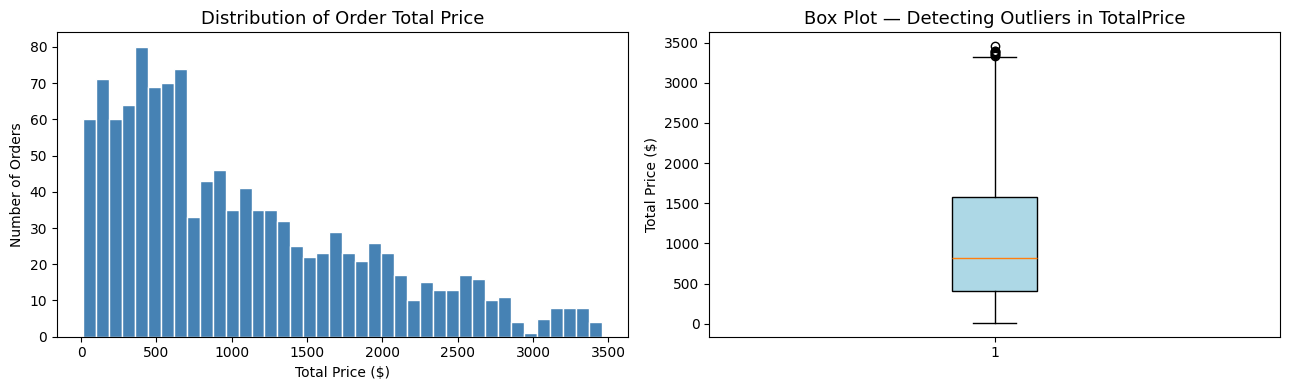

Outliers detected (IQR method): 8 orders


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['TotalPrice'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Order Total Price', fontsize=13)
axes[0].set_xlabel('Total Price ($)')
axes[0].set_ylabel('Number of Orders')

axes[1].boxplot(df['TotalPrice'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Box Plot — Detecting Outliers in TotalPrice', fontsize=13)
axes[1].set_ylabel('Total Price ($)')

plt.tight_layout()
plt.show()

Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['TotalPrice'] < Q1 - 1.5*IQR) | (df['TotalPrice'] > Q3 + 1.5*IQR)]
print(f"Outliers detected (IQR method): {len(outliers)} orders")


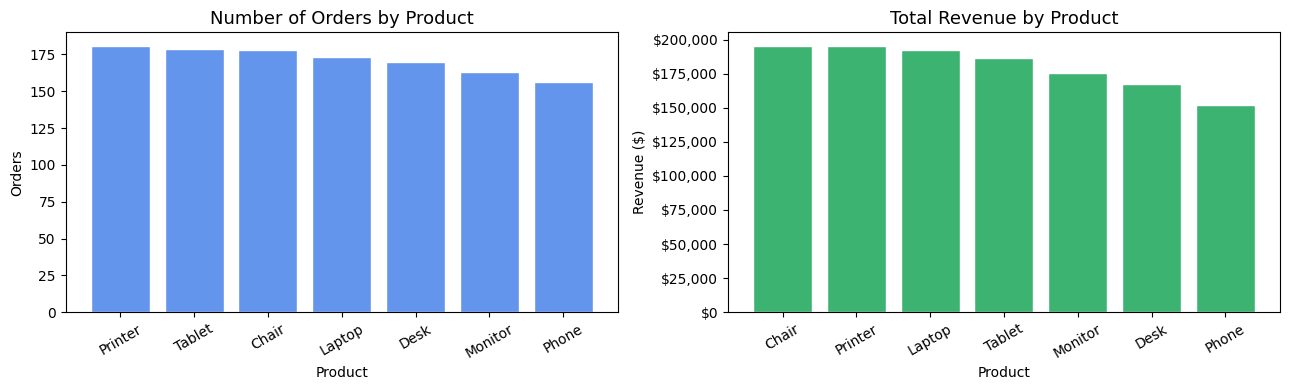

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

product_counts   = df['Product'].value_counts()
product_revenue  = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

axes[0].bar(product_counts.index, product_counts.values, color='cornflowerblue', edgecolor='white')
axes[0].set_title('Number of Orders by Product', fontsize=13)
axes[0].set_xlabel('Product'); axes[0].set_ylabel('Orders')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(product_revenue.index, product_revenue.values, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Total Revenue by Product', fontsize=13)
axes[1].set_xlabel('Product'); axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

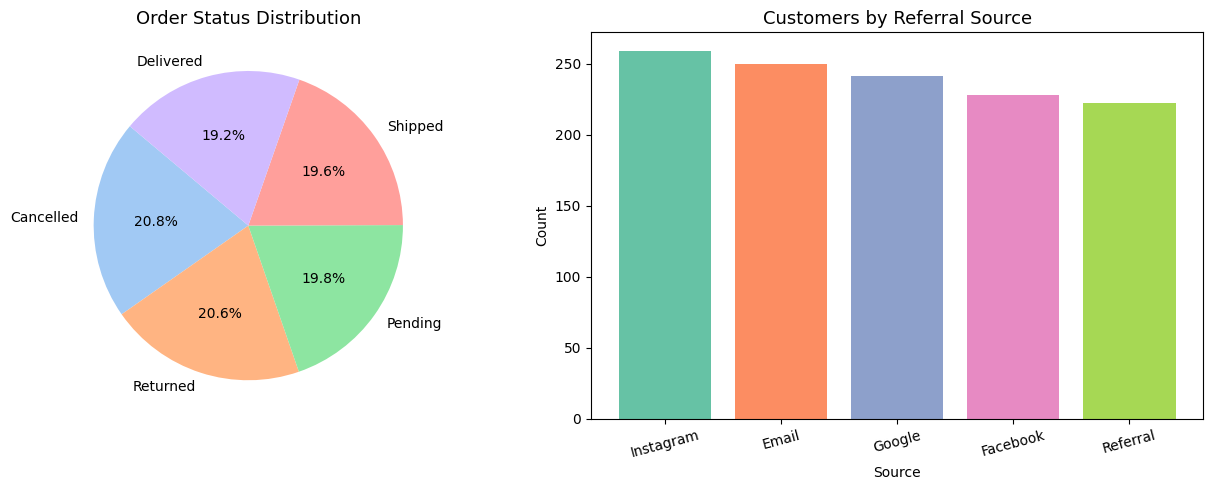

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

status_counts = df['OrderStatus'].value_counts()
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel'), startangle=140)
axes[0].set_title('Order Status Distribution', fontsize=13)

ref_counts = df['ReferralSource'].value_counts()
axes[1].bar(ref_counts.index, ref_counts.values, color=sns.color_palette('Set2'))
axes[1].set_title('Customers by Referral Source', fontsize=13)
axes[1].set_xlabel('Source'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

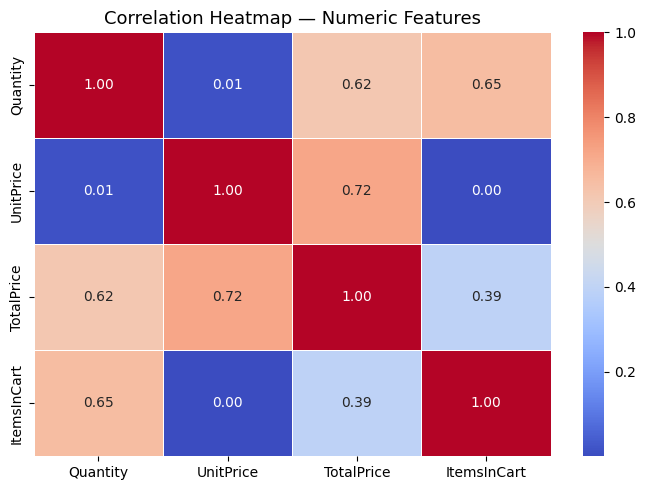

In [24]:
plt.figure(figsize=(7, 5))
numeric_cols = df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']]
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()


#Task 4

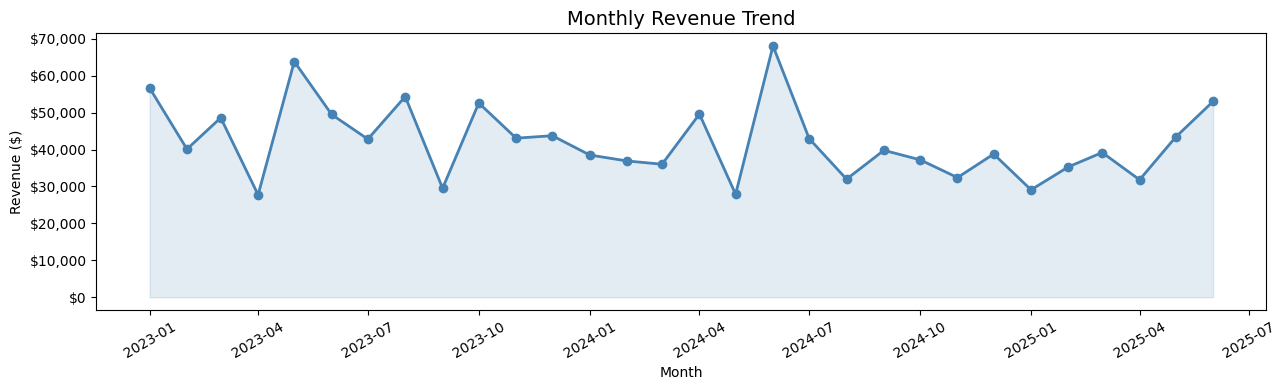

In [25]:
monthly = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()
monthly['Period'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))
monthly = monthly.sort_values('Period')

plt.figure(figsize=(13, 4))
plt.plot(monthly['Period'], monthly['TotalPrice'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(monthly['Period'], monthly['TotalPrice'], alpha=0.15, color='steelblue')
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month'); plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

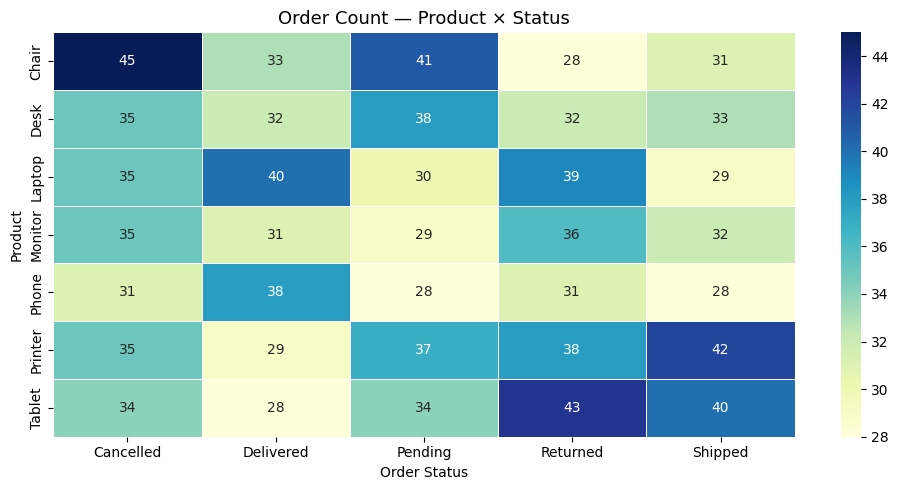

In [26]:
pivot = df.groupby(['Product', 'OrderStatus']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5)
plt.title('Order Count — Product × Status', fontsize=13)
plt.xlabel('Order Status'); plt.ylabel('Product')
plt.tight_layout()
plt.show()

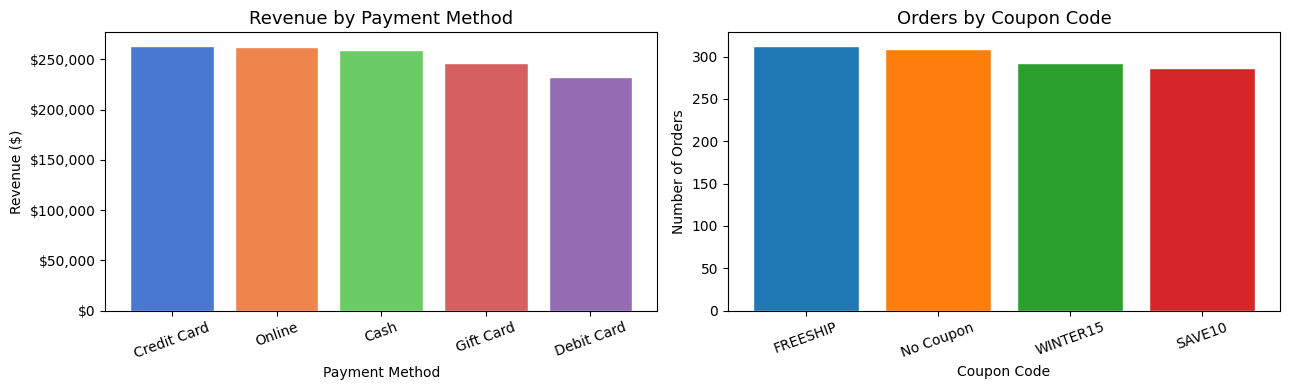

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pay_rev = df.groupby('PaymentMethod')['TotalPrice'].sum().sort_values(ascending=False)
axes[0].bar(pay_rev.index, pay_rev.values, color=sns.color_palette('muted'), edgecolor='white')
axes[0].set_title('Revenue by Payment Method', fontsize=13)
axes[0].set_xlabel('Payment Method'); axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=20)

coupon_counts = df['CouponCode'].value_counts()
axes[1].bar(coupon_counts.index, coupon_counts.values,
            color=sns.color_palette('tab10', len(coupon_counts)), edgecolor='white')
axes[1].set_title('Orders by Coupon Code', fontsize=13)
axes[1].set_xlabel('Coupon Code'); axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

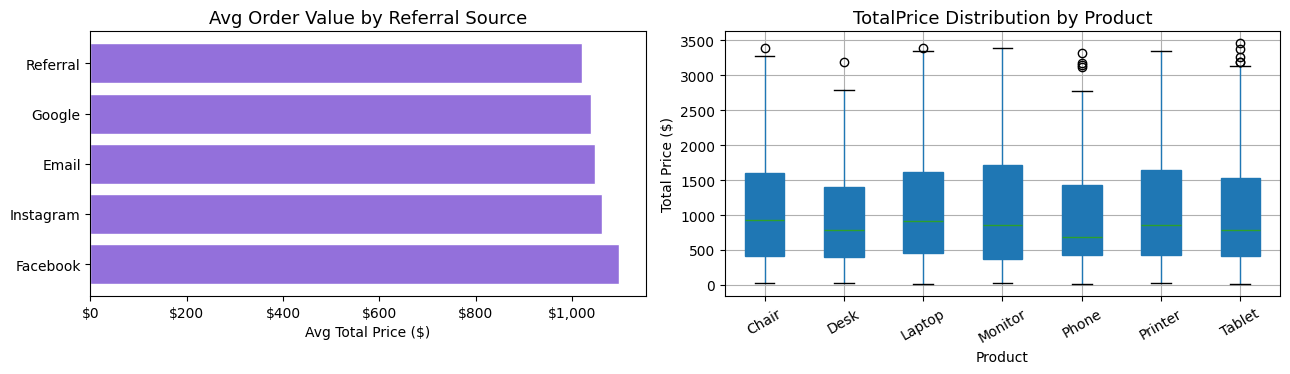

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

avg_ref = df.groupby('ReferralSource')['TotalPrice'].mean().sort_values(ascending=False)
axes[0].barh(avg_ref.index, avg_ref.values, color='mediumpurple', edgecolor='white')
axes[0].set_title('Avg Order Value by Referral Source', fontsize=13)
axes[0].set_xlabel('Avg Total Price ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Quantity distribution by product (box plots)
df.boxplot(column='TotalPrice', by='Product', ax=axes[1],
           patch_artist=True, figsize=(13,4))
axes[1].set_title('TotalPrice Distribution by Product', fontsize=13)
axes[1].set_xlabel('Product'); axes[1].set_ylabel('Total Price ($)')
plt.suptitle('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#Task 5


In [29]:
df_model = df.copy()
le = LabelEncoder()
for col in ['Product', 'PaymentMethod', 'ReferralSource', 'CouponCode', 'OrderStatus']:
    df_model[col + '_enc'] = le.fit_transform(df_model[col])

features = ['Quantity', 'UnitPrice', 'ItemsInCart',
            'Product_enc', 'PaymentMethod_enc', 'ReferralSource_enc', 'CouponCode_enc']

X = df_model[features]
print("Features used:", features)
print("Sample encoded data:")
X.head()


Features used: ['Quantity', 'UnitPrice', 'ItemsInCart', 'Product_enc', 'PaymentMethod_enc', 'ReferralSource_enc', 'CouponCode_enc']
Sample encoded data:


,Quantity,UnitPrice,ItemsInCart,Product_enc,PaymentMethod_enc,ReferralSource_enc,CouponCode_enc
0,5,570.62,7,3,2,3,2
1,2,151.35,3,4,4,4,2
2,5,550.68,8,6,1,0,0
3,1,273.19,5,0,2,1,2
4,4,626.01,8,5,4,0,2


In [30]:
y_reg = df_model['TotalPrice']

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred_reg = reg_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_reg)
r2  = r2_score(y_test, y_pred_reg)

print("=" * 45)
print("  MODEL 1: Linear Regression — TotalPrice")
print("=" * 45)
print(f"  Mean Absolute Error : ${mae:.2f}")
print(f"  R² Score            : {r2:.4f}  ({r2*100:.1f}% variance explained)")

  MODEL 1: Linear Regression — TotalPrice
  Mean Absolute Error : $210.88
  R² Score            : 0.8919  (89.2% variance explained)


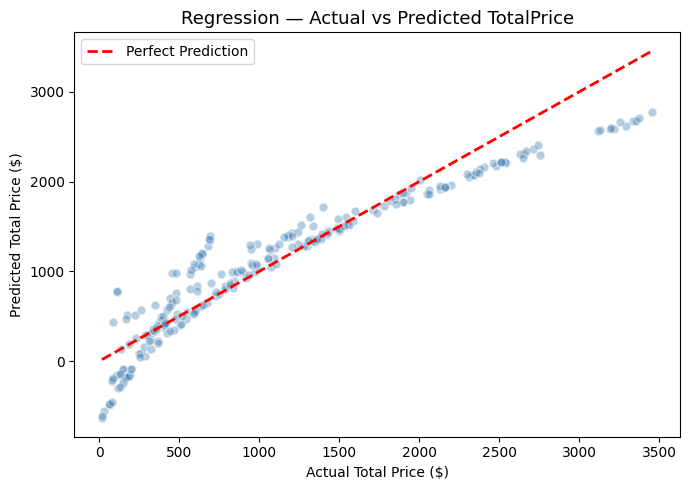

In [31]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_reg, alpha=0.4, color='steelblue', edgecolors='white', s=40)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Total Price ($)')
plt.ylabel('Predicted Total Price ($)')
plt.title('Regression — Actual vs Predicted TotalPrice', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
df_model['IsDelivered'] = (df_model['OrderStatus'] == 'Delivered').astype(int)
y_clf = df_model['IsDelivered']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y_clf, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train2_sc = scaler.fit_transform(X_train2)
X_test2_sc  = scaler.transform(X_test2)

clf_model = LogisticRegression(max_iter=300, random_state=42)
clf_model.fit(X_train2_sc, y_train2)
y_pred_clf = clf_model.predict(X_test2_sc)

acc = accuracy_score(y_test2, y_pred_clf)

print("=" * 45)
print("  MODEL 2: Logistic Regression — Delivered?")
print("=" * 45)
print(f"  Accuracy: {acc*100:.2f}%")
print()
print(classification_report(y_test2, y_pred_clf, target_names=['Not Delivered', 'Delivered'], zero_division=0))

  MODEL 2: Logistic Regression — Delivered?
  Accuracy: 82.92%

               precision    recall  f1-score   support

Not Delivered       0.83      1.00      0.91       199
    Delivered       0.00      0.00      0.00        41

     accuracy                           0.83       240
    macro avg       0.41      0.50      0.45       240
 weighted avg       0.69      0.83      0.75       240



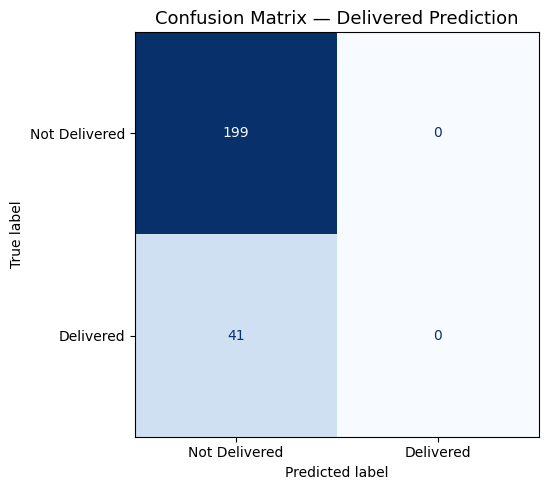

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test2, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Delivered', 'Delivered'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Delivered Prediction', fontsize=13)
plt.tight_layout()
plt.show()

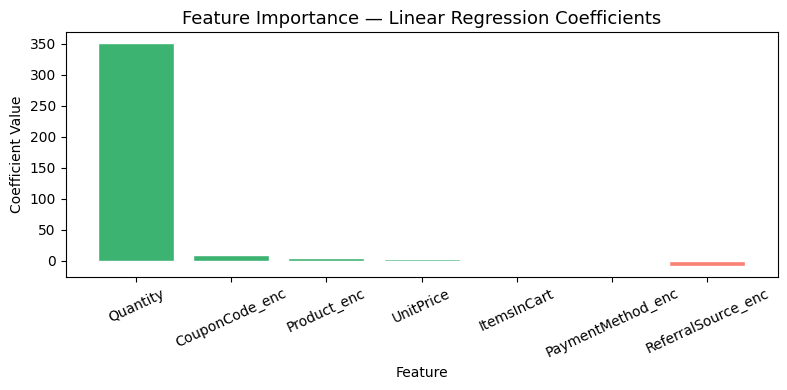

In [36]:
coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': reg_model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8, 4))
colors = ['mediumseagreen' if c > 0 else 'salmon' for c in coef_df['Coefficient']]
plt.bar(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.title('Feature Importance — Linear Regression Coefficients', fontsize=13)
plt.xlabel('Feature'); plt.ylabel('Coefficient Value')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()